In [1]:
!pip install torch torchvision --upgrade --quiet
!pip install diffusers==0.30.0 transformers==4.45.0 accelerate==0.33.0 safetensors==0.4.3 --quiet
!pip install pillow --quiet

In [2]:
!pip install diffusers==0.29.2 transformers==4.46.2 accelerate==0.33.0 safetensors==0.4.3
!pip install torch torchvision --index-url https://download.pytorch.org/whl/cu121

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 44.1/44.1 kB 3.8 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 61.0/61.0 kB 5.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.2/2.2 MB 37.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 10.0/10.0 MB 58.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 315.1/315.1 kB 27.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.2/1.2 MB 53.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 18.0/18.0 MB 67.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.0/3.0 MB 80.1 MB/s eta 0:00:00
  Attempting uninstall: safetensors
    Found existing installation: safetensors 0.6.2
    Uninstalling safetensors-0.6.2:
      Successfully uninstalled safetensors-0.6.2
  Attempting uninstall: numpy
    Found existing installation: numpy 2.0.2
    Uninstalling numpy-2.0.2:
      Successfully uninstalled numpy-2.0.2
  Attempting uninstall: tokenizers
    Found exist

Looking in indexes: https://download.pytorch.org/whl/cu121


In [1]:
from diffusers import StableDiffusionImg2ImgPipeline
from PIL import Image
import torch

model = "runwayml/stable-diffusion-v1-5"

pipe = StableDiffusionImg2ImgPipeline.from_pretrained(model, torch_dtype=torch.float16)
pipe = pipe.to("cuda")

print("Model is successfully loaded")

The cache for model files in Transformers v4.22.0 has been updated. Migrating your old cache. This is a one-time only operation. You can interrupt this and resume the migration later on by calling `transformers.utils.move_cache()`.


0it [00:00, ?it/s]

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


Loading pipeline components...:   0%|          | 0/7 [00:00<?, ?it/s]

Model is successfully loaded


In [2]:
from google.colab import files
uploaded = files.upload()

image_path = list(uploaded.keys())[0]
image = Image.open(image_path).convert("RGB").resize((512, 512))

Saving kitten.avif to kitten.avif


  0%|          | 0/45 [00:00<?, ?it/s]

  0%|          | 0/45 [00:00<?, ?it/s]

  0%|          | 0/45 [00:00<?, ?it/s]

  0%|          | 0/45 [00:00<?, ?it/s]


Textual Prompt: A cat painted in anime style


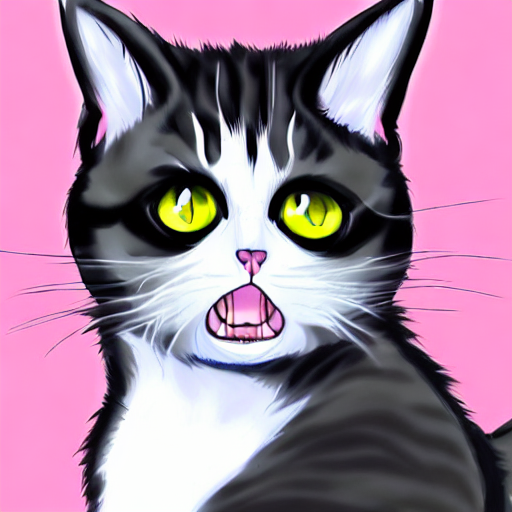


Textual Prompt: An oil painting of cat


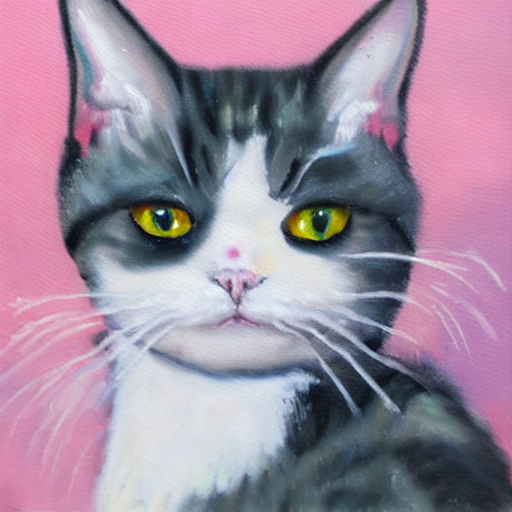


Textual Prompt: A cat in a sunset setting


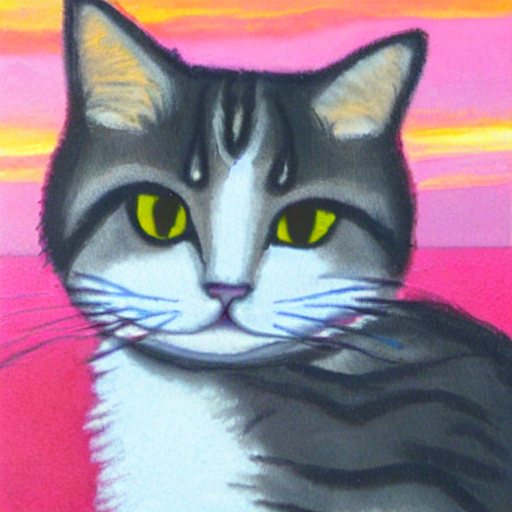


Textual Prompt: A kitten in cyber-punk setting


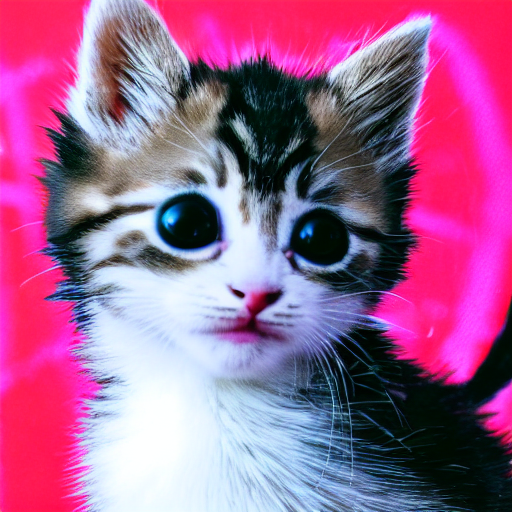

In [7]:
prompts = [
    "A cat painted in anime style",
    "An oil painting of cat",
    "A cat in a sunset setting",
    "A kitten in cyber-punk setting"
]

results = []
for p in prompts:
    image = pipe(prompt=p, image=image, strength=0.9, guidance_scale=8.5).images[0]
    results.append((p, image))

for prompt, img in results:
    print(f"\nTextual Prompt: {prompt}")
    display(img)